## Generating idealized synthetic data cube: imaging only

This notebook demonstrates the generation of synthetic broad-band images. To generate synthetic imaging data cube using ``GalaxySynthesizer``, we first need to set up filters and their transmission curves. 

### Setting up filter transmission curves
The ``filters`` input is a list containing filter names (arbitrary) in string, whereas ``filter_transmission_path`` input is a Dictionary of paths to text files containing the transmission function. Keys are filter names (as listed in ``filters``), values are file paths. Each text file has two columns: wavelength, transmission.

Alternatively, if you have [piXedfit](https://pixedfit.readthedocs.io/en/latest/) installed, you can set up these inputs easily using ``make_filter_transmission_text_pixedfit`` function. It will create a dictionary and text files containing the filter transmission curves taken from the internal piXedfit package. For this to work, you need to use filter naming in piXedfit. Below is an example script for this:

In [1]:
from galsyn.utils import make_filter_transmission_text_pixedfit

filters = ['hst_acs_f435w', 'hst_acs_f606w', 'hst_acs_f814w', 'hst_wfc3_ir_f110w', 'hst_wfc3_ir_f125w', 
            'hst_wfc3_ir_f140w', 'hst_wfc3_ir_f160w', 'jwst_nircam_f090w', 'jwst_nircam_f115w', 
            'jwst_nircam_f140m', 'jwst_nircam_f150w', 'jwst_nircam_f200w', 'jwst_nircam_f250m', 
            'jwst_nircam_f277w', 'jwst_nircam_f300m', 'jwst_nircam_f356w', 'jwst_nircam_f410m', 
            'jwst_nircam_f444w', 'jwst_nircam_f460m', 'jwst_nircam_f480m']

filter_transmission_path = make_filter_transmission_text_pixedfit(filters, output_dir="filters")

Created directory: filters


### Generating synthetic imaging data cube
Now, we run the synthesis process using ``GalaxySynthesizer``. The following script demonstrates the generation of imaging data cube with line-of-sight dust-attenuation modeling method and the modified Calzetti dust law with a dynamic slope and bump strength that depends on $A_{V}$.   

In [ ]:
from galsyn import GalaxySynthesizer
from galsyn.dust import relation_AVslope
from galsyn.simutils_tng import get_snap_z

# Your personal API key from the IllustrisTNG website
api_key = "your_api_key"

# Specify simulation parameters
sim = 'TNG50-1'         # The TNG simulation run
snap_number = 39        # The snapshot index (e.g., z ~ 1.5 in IllustrisTNG)
subhalo_id = 107965     # The subhalo ID

# Retrieve the exact redshift for the given snapshot number using the TNG API
z = get_snap_z(snap_number, api_key=api_key)
print ('Redshift: %lf' % z)

# Define the output path for the standardized file, generated using the script in Example 1
sim_file = f'sim_file_tng_{int(snap_number)}_{int(subhalo_id)}.hdf5'

gs = GalaxySynthesizer(sim_file, z=z, filters=filters, filter_transmission_path=filter_transmission_path)

gs.ssp_filepath = 'ssp_fsps.hdf5'         # path to the FSPS SSP grids generated in Example 2
gs.ssp_interpolation_method = 'nearest'

gs.dim_kpc = 90                # Image side length in kpc
gs.smoothing_length = 0.15     # Smoothing length of the simulation in kpc
gs.pix_arcsec = 0.03           # Output pixel scale in arcseconds

gs.flux_unit = 'MJy/sr'        # Desired unit for the output FITS file

gs.polar_angle_deg = 0.0       # Polar angle or inclination
gs.azimuth_angle_deg = 0.0     # azimuth angle or rotation in the xy-plane

# Dust attenuation modeling method
gs.dust_method = 'los'             # line-of-sight method

# modified Calzetti et al. (2000) with variable slope and Bump
gs.dust_law = 0                  

# Apply dynamic slope (steeper for lower AV and shallower for higher AV) 
dict_AV_dustindex = relation_AVslope(model_name="salim18")
gs.dust_index = dict_AV_dustindex

# Apply dynamic Bump strength tied to the slope (Kriek & Conroy 2013)
dict_AV_bump_amp = {}
dict_AV_bump_amp['AV'] = dict_AV_dustindex['AV']
dict_AV_bump_amp['bump_amp'] = 0.85 - 1.9*dict_AV_dustindex['dust_index']
gs.bump_amp = dict_AV_bump_amp 

# Set fixed Bump width
gs.bump_dwave = 0.035            # in micron

gs.dust_eta = 1.0                # Ratio of AV in birth clouds vs diffuse ISM
gs.dust_index_bc = -0.7          # Power-law slope for birth clouds

gs.ncpu = 5                      # number of CPU cores to use
gs.output_pixel_spectra = False  # Generate broadband images only (not including spectra)

gs.name_out_img = f'galsyn_{int(snap_number)}_{int(subhalo_id)}_photo.fits'

# Run the synthetis process
gs.run_synthesis()

Redshift: 1.531239
Using specified SSP filepath: ssp_fsps.hdf5
Processing sim_file_tng_39_107965.hdf5


Processing pixels:   0%|          | 0/360000 [00:00<?, ?it/s]

Galaxy image synthesis completed successfully and results saved to FITS file: galsyn_39_107965_photo.fits


### Check the data cube

First, we check what's inside the FITS file

In [1]:
from astropy.io import fits

cube = fits.open('galsyn_39_107965_photo.fits')
cube.info()

Filename: galsyn_39_107965_photo.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (345, 345)   float64   
  1  NODUST_HST_ACS_F435W    1 ImageHDU        11   (345, 345)   float64   
  2  NODUST_HST_ACS_F606W    1 ImageHDU        11   (345, 345)   float64   
  3  NODUST_HST_ACS_F814W    1 ImageHDU        11   (345, 345)   float64   
  4  NODUST_HST_WFC3_IR_F110W    1 ImageHDU        11   (345, 345)   float64   
  5  NODUST_HST_WFC3_IR_F125W    1 ImageHDU        11   (345, 345)   float64   
  6  NODUST_HST_WFC3_IR_F140W    1 ImageHDU        11   (345, 345)   float64   
  7  NODUST_HST_WFC3_IR_F160W    1 ImageHDU        11   (345, 345)   float64   
  8  NODUST_JWST_NIRCAM_F090W    1 ImageHDU        11   (345, 345)   float64   
  9  NODUST_JWST_NIRCAM_F115W    1 ImageHDU        11   (345, 345)   float64   
 10  NODUST_JWST_NIRCAM_F140M    1 ImageHDU        11   (345, 345)   float64   
 11  NODUST_JWST_NIRCAM_F150W    1 ImageHDU   

Next, we plot stamp images of some filters and composite RGB image

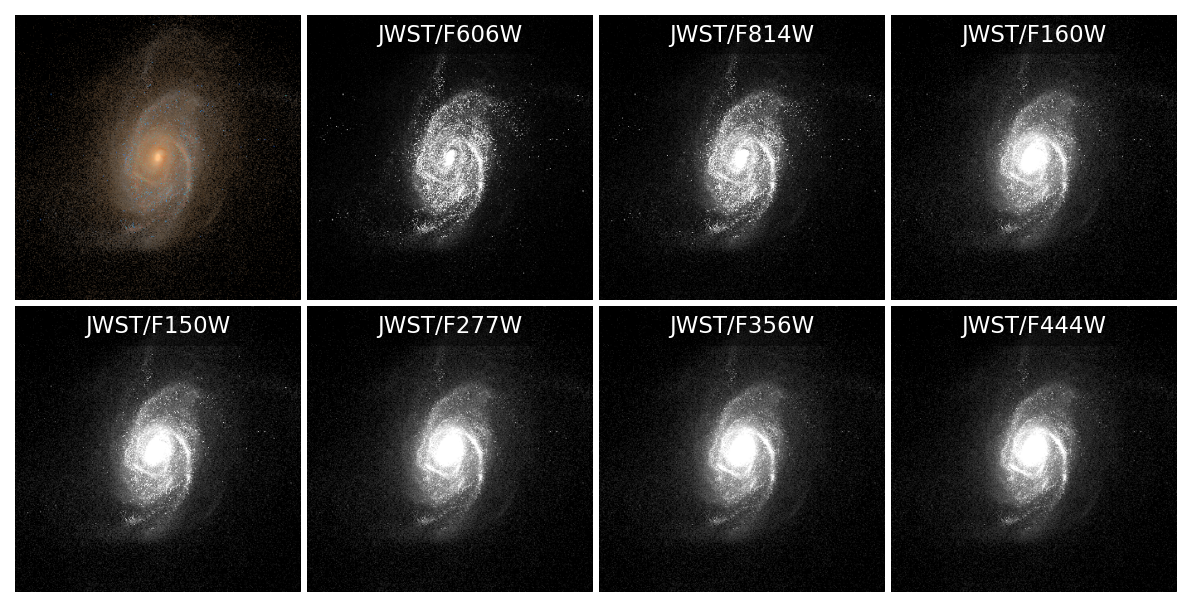

In [6]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm, make_lupton_rgb

# Filter configuration
fils = ['hst_acs_f606w', 'hst_acs_f814w', 'hst_wfc3_ir_f160w', 'jwst_nircam_f150w', 
        'jwst_nircam_f277w', 'jwst_nircam_f356w', 'jwst_nircam_f444w']
filnames = ['JWST/F606W', 'JWST/F814W', 'JWST/F160W', 'JWST/F150W', 
            'JWST/F277W', 'JWST/F356W', 'JWST/F444W']
nbands = len(fils)

# RGB components (using JWST NIRCam filters)
rgb_fils = ['jwst_nircam_f115w', 'jwst_nircam_f150w', 'jwst_nircam_f200w']

nrows, ncols = 2, 4
fig = plt.figure(figsize=(ncols*2.5, nrows*2.5), dpi=150)

# RGB Composite
ax_rgb = fig.add_subplot(nrows, ncols, 1)
factor = 3e+3

# Access data using the standard 'DUST[FILTER]' extension name 
r = cube[f'DUST_{rgb_fils[2]}'].data * factor
g = cube[f'DUST_{rgb_fils[1]}'].data * factor
b = cube[f'DUST_{rgb_fils[0]}'].data * factor

rgb = make_lupton_rgb(r, g, b, stretch=20, Q=15)
ax_rgb.imshow(rgb, origin='lower')
ax_rgb.axis('off') # Cleanly removes all ticks and labels

# Individual Grayscale Bands
for ii in range(nbands):
    ax = fig.add_subplot(nrows, ncols, ii+2)
    
    # Access dust-attenuated imaging data 
    data = cube[f'DUST_{fils[ii]}'].data
    
    # Apply square-root normalization to improve dynamic range visibility
    norm = simple_norm(data, 'sqrt', percent=97.5)
    ax.imshow(data, norm=norm, origin='lower', cmap='gray')
    ax.axis('off')

    # Add filter labels with a small background box for readability
    ax.text(0.5, 0.93, filnames[ii], color='white', fontsize=11,
            ha='center', va='center', transform=ax.transAxes,
            bbox=dict(facecolor='black', alpha=0.4, lw=0))

plt.subplots_adjust(hspace=0.02, wspace=0.02)
plt.show()